# Projeto 5 - Transformers

## Classificação semântica e busca vetorial de projetos de P&D&I com BERT + NER de domínio

Disciplina: Aprendizagem Profunda (Deep Learning)

Este projeto usa a base de projetos de Pesquisa, Desenvolvimento & Inovação (P&D&I) (dadosTextosCientificos.tsv). A ideia central é usar um Transformer
pré-treinado em português, o BERTimbau (neuralmind/bert-base-portuguese-cased), para
representar cada projeto como um vetor numérico e, a partir disso, fazer duas coisas:
(1) uma busca semântica, que recebe uma frase qualquer e retorna os projetos mais parecidos
por significado, mesmo sem usar as mesmas palavras; e (2) um agrupamento automático dos
projetos por área tecnológica, combinando os embeddings do BERT com TF-IDF e com entidades
extraídas por NER.

O fluxo seguido foi: primeiro limpeza e pré-processamento do texto com spaCy, depois análise
de POS e NER, em seguida a parte de Transformers (que é a base do projeto), fechando com a
busca vetorial (o MiniLAB) e a clusterização como uma aplicação prática de tudo junto.


## 0. Setup - instalação e imports

In [1]:
# Instalação das bibliotecas necessárias
!pip -q install --upgrade spacy transformers unidecode wordcloud kagglehub
!python -m spacy download pt_core_news_lg -q
print("Instalação concluída.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Instalação concluída.


In [2]:
import os, re, json, random, warnings, unicodedata
from collections import Counter

import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModel

import spacy
from spacy.pipeline import EntityRuler

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {DEVICE}")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Dispositivo em uso: cuda
GPU: Tesla T4


## 1. Carregamento da base de dados

O código busca o arquivo dadosTextosCientificos.tsv em alguns caminhos comuns; se não
encontrar, tenta baixar pelo kagglehub (só funciona se houver credencial do Kaggle
configurada); e, se nada disso der certo, abre a caixa de upload manual do Colab para
seleção do arquivo. A leitura também é tolerante a encoding, já que essa base às vezes vem
gravada em latin-1/cp1252 em vez de utf-8.

In [3]:
CAMINHOS_CANDIDATOS = [
    "/content/dadosTextosCientificos.tsv",
    "/content/drive/MyDrive/dadosTextosCientificos.tsv",
    "/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv",
    "dadosTextosCientificos.tsv",
]

caminho_dados = next((p for p in CAMINHOS_CANDIDATOS if os.path.exists(p)), None)

# Tentativa 2: kagglehub
if caminho_dados is None:
    try:
        import kagglehub
        pasta = kagglehub.dataset_download("georgekurokijr/dl-2024")
        for f in os.listdir(pasta):
            if f.lower().endswith((".tsv", ".csv")):
                caminho_dados = os.path.join(pasta, f)
                break
        print("Dataset localizado via kagglehub:", caminho_dados)
    except Exception as e:
        print(f"kagglehub indisponível ou sem credenciais ({type(e).__name__}). Seguindo para upload manual.")

# Tentativa 3: upload manual
if caminho_dados is None:
    try:
        from google.colab import files
        print("Arquivo não encontrado automaticamente.")
        print("Selecione 'dadosTextosCientificos.tsv' na caixa de upload abaixo:")
        uploaded = files.upload()
        caminho_dados = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "dadosTextosCientificos.tsv não encontrado. Coloque o arquivo na mesma pasta do notebook."
        )

print("\nCaminho final do dataset:", caminho_dados)


Using Colab cache for faster access to the 'dl-2024' dataset.
Dataset localizado via kagglehub: /kaggle/input/dl-2024/dadosTextosCientificos.tsv

Caminho final do dataset: /kaggle/input/dl-2024/dadosTextosCientificos.tsv


In [4]:
def carregar_dataset(caminho):
    # Leitura resiliente a encoding (utf-8 -> latin-1 -> cp1252).
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            df_ = pd.read_csv(caminho, sep="\t", encoding=enc)
            print(f"Dataset carregado com encoding '{enc}'. Shape: {df_.shape}")
            return df_
        except (UnicodeDecodeError, pd.errors.ParserError):
            continue
    raise ValueError("Não foi possível ler o arquivo com os encodings testados (utf-8/latin-1/cp1252).")

df_raw = carregar_dataset(caminho_dados)
df_raw.head(3)


Dataset carregado com encoding 'latin-1'. Shape: (2725, 2)


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...


In [5]:
print("Colunas originais:", df_raw.columns.tolist())
print("\nValores nulos por coluna:")
print(df_raw.isna().sum())
print("\nTotal de registros:", len(df_raw))


Colunas originais: ['Título_Público', 'Descricao_pública']

Valores nulos por coluna:
Título_Público       3
Descricao_pública    4
dtype: int64

Total de registros: 2725


## 2. Manipulação de linguagem - normalização e curadoria

Nesta etapa os nomes das colunas são padronizados, as colunas de título e descrição são
localizadas automaticamente (a base varia um pouco de nome dependendo de como foi exportada),
os dois campos são unidos num texto só por projeto, e linhas vazias, duplicadas ou de ruído
administrativo (tipo "confidencial", "a definir") são removidas.

In [6]:
def normaliza_nome_coluna(col):
    col = unidecode(str(col)).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col).strip("_")
    return col

df = df_raw.copy()
df.columns = [normaliza_nome_coluna(c) for c in df.columns]
print(df.columns.tolist())


['titulo_publico', 'descricao_publica']


In [7]:
CANDIDATOS_TITULO = ["titulo_publico", "titulo", "titulo_projeto", "nome_projeto", "nome_do_projeto"]
CANDIDATOS_DESC = [
    "descricao_publica", "descricao", "descricao_do_projeto", "resumo",
    "objetivo", "descricao_projeto", "resumo_publico", "sumario",
]

def acha_coluna(candidatos, colunas):
    for c in candidatos:
        if c in colunas:
            return c
    for c in colunas:
        if any(k in c for k in candidatos):
            return c
    return None

col_titulo = acha_coluna(CANDIDATOS_TITULO, df.columns)
col_desc = acha_coluna(CANDIDATOS_DESC, df.columns)
print("Coluna de título:", col_titulo)
print("Coluna de descrição:", col_desc)
assert col_titulo and col_desc, "Não foi possível localizar as colunas de título/descrição — confira df.columns."


Coluna de título: titulo_publico
Coluna de descrição: descricao_publica


In [8]:
def limpa_texto(txt):
    if pd.isna(txt):
        return ""
    txt = str(txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()

df["titulo_limpo"] = df[col_titulo].apply(limpa_texto)
df["descricao_limpa"] = df[col_desc].apply(limpa_texto)
df["texto"] = (df["titulo_limpo"] + ". " + df["descricao_limpa"]).str.strip(". ").str.strip()

# Ruído administrativo comum nesta base
PADROES_RUIDO = re.compile(
    r"confidencial|^a definir$|projeto cancelado|teste de sistema|^sem descri[cç][aã]o$",
    flags=re.IGNORECASE,
)

antes = len(df)
df = df[df["texto"].str.len() > 15].copy()
df = df[~df["texto"].str.contains(PADROES_RUIDO, na=False)]
df = df.drop_duplicates(subset="texto").reset_index(drop=True)
df["id_projeto"] = df.index

print(f"Registros antes da curadoria: {antes} | depois: {len(df)}")
df[["id_projeto", "texto"]].head(3)


Registros antes da curadoria: 2725 | depois: 2705


,id_projeto,texto
0,0,Açúcar de frutas e aplicação em bolos como sub...
1,1,Desenvolver uma linha de farofas com castanhas...
2,2,Desenvolvimento de cobertura líquida para sorv...


## 3. Pré-processamento de texto com spaCy

O modelo pt_core_news_lg do spaCy é usado para tokenizar, lematizar e remover stopwords -
tanto as genéricas do português quanto algumas de domínio adicionadas manualmente, como
"projeto", "desenvolvimento", "empresa" (aparecem em quase todo registro e não ajudam a
diferenciar os temas). O texto processado (texto_processado) alimenta o TF-IDF mais adiante;
já o texto original (texto) é o que vai para o BERT, que lida bem sozinho com pontuação e
flexões.

In [9]:
nlp = spacy.load("pt_core_news_lg")
print("Pipeline spaCy:", nlp.pipe_names)


Pipeline spaCy: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']


In [10]:
STOPWORDS_PT = set(nlp.Defaults.stop_words)
STOPWORDS_DOMINIO = {
    "projeto", "projetos", "empresa", "empresas", "desenvolvimento", "desenvolveu",
    "desenvolver", "objetivo", "pesquisa", "estudo", "produto", "produtos",
    "tecnologia", "processo", "novo", "nova", "sistema", "aplicacao", "aplicado",
    "atraves", "assim", "sendo", "sobre", "forma", "modo", "visando", "buscando",
    "brasil", "brasileiro", "brasileira",
}
STOPWORDS_FINAL = {unidecode(w.lower()) for w in STOPWORDS_PT | STOPWORDS_DOMINIO}

def preprocessa_spacy(doc):
    # Lematização + remoção de stopwords/pontuação/números a partir de um Doc já processado.
    tokens = [
        tok.lemma_.lower()
        for tok in doc
        if not tok.is_punct
        and not tok.is_space
        and not tok.like_num
        and len(tok.text) > 2
        and unidecode(tok.lemma_.lower()) not in STOPWORDS_FINAL
    ]
    return " ".join(tokens)

# Processamento em lote (nlp.pipe é bem mais rápido que aplicar nlp() em loop)
docs = list(nlp.pipe(df["texto"].tolist(), batch_size=64))
df["texto_processado"] = [preprocessa_spacy(d) for d in docs]

df[["texto", "texto_processado"]].head(3)


,texto,texto_processado
0,Açúcar de frutas e aplicação em bolos como sub...,açúcar fruta bolo substituto sacarose uso inov...
1,Desenvolver uma linha de farofas com castanhas...,linha farofa castanha adição proteína animal u...
2,Desenvolvimento de cobertura líquida para sorv...,cobertura líquido sorvete considerar país biod...


Tokens médios por projeto — antes: 59.6 | depois: 31.7
Vocabulário (aprox.) — antes: 20747 | depois: 11411


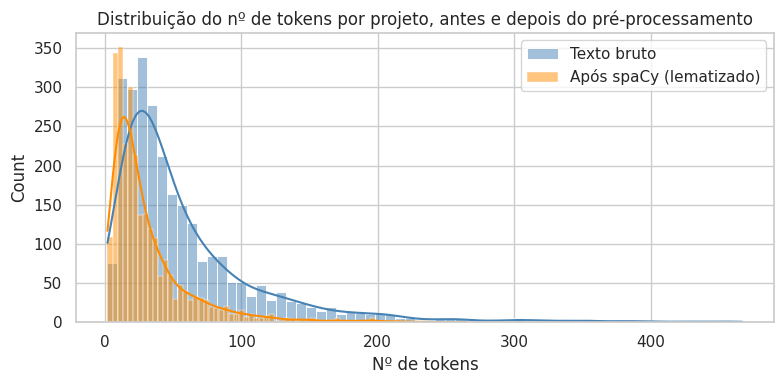

In [11]:
# Estatísticas de pré-processamento
n_tokens_antes = df["texto"].str.split().apply(len)
n_tokens_depois = df["texto_processado"].str.split().apply(len)
vocab_antes = len(set(" ".join(df["texto"]).lower().split()))
vocab_depois = len(set(" ".join(df["texto_processado"]).split()))

print(f"Tokens médios por projeto — antes: {n_tokens_antes.mean():.1f} | depois: {n_tokens_depois.mean():.1f}")
print(f"Vocabulário (aprox.) — antes: {vocab_antes} | depois: {vocab_depois}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(n_tokens_antes, color="steelblue", label="Texto bruto", kde=True, alpha=0.5)
sns.histplot(n_tokens_depois, color="darkorange", label="Após spaCy (lematizado)", kde=True, alpha=0.5)
ax.set_title("Distribuição do nº de tokens por projeto, antes e depois do pré-processamento")
ax.set_xlabel("Nº de tokens")
ax.legend()
plt.tight_layout()
plt.show()


## 4. POS Tagging (Part of Speech)

Aqui é contada a distribuição de classes gramaticais em todo o corpus, o que ajuda a entender
o "estilo" dos textos (resumo técnico costuma ter bastante substantivo e adjetivo). Também é
mostrado um exemplo anotado token a token para visualizar melhor o resultado.

In [12]:
pos_legenda = {
    "NOUN": "Substantivo", "VERB": "Verbo", "ADJ": "Adjetivo", "ADV": "Advérbio",
    "PROPN": "Nome próprio", "DET": "Determinante", "ADP": "Preposição",
    "CCONJ": "Conj. coordenativa", "SCONJ": "Conj. subordinativa", "PRON": "Pronome",
    "AUX": "Verbo auxiliar", "NUM": "Numeral", "PUNCT": "Pontuação",
}

pos_counts = Counter(
    tok.pos_ for doc in docs for tok in doc if not tok.is_space and tok.pos_ != ""
)
pos_df = pd.DataFrame(pos_counts.most_common(12), columns=["POS", "Frequência"])
pos_df["Classe (PT)"] = pos_df["POS"].map(lambda x: pos_legenda.get(x, x))
pos_df


,POS,Frequência,Classe (PT)
0,NOUN,52220,Substantivo
1,ADP,39155,Preposição
2,PUNCT,15284,Pontuação
3,ADJ,13941,Adjetivo
4,VERB,13544,Verbo
5,PROPN,13283,Nome próprio
6,DET,12533,Determinante
7,CCONJ,6679,Conj. coordenativa
8,ADV,2732,Advérbio
9,AUX,2149,Verbo auxiliar


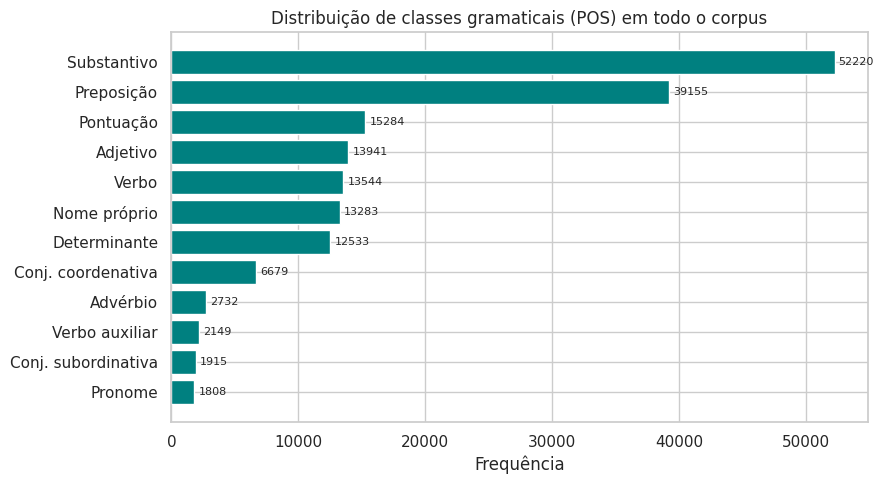

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(pos_df["Classe (PT)"][::-1], pos_df["Frequência"][::-1], color="teal", edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set_title("Distribuição de classes gramaticais (POS) em todo o corpus")
ax.set_xlabel("Frequência")
plt.tight_layout()
plt.show()


In [14]:
# Exemplo anotado token a token
exemplo = df["texto"].iloc[0]
doc_exemplo = nlp(exemplo)
print("TEXTO:", exemplo[:200], "...\n")
tabela_exemplo = pd.DataFrame(
    [(t.text, t.pos_, pos_legenda.get(t.pos_, t.pos_), t.lemma_, t.dep_) for t in doc_exemplo if not t.is_space],
    columns=["Token", "POS", "Classe", "Lema", "Dependência sintática"],
)
tabela_exemplo.head(20)


TEXTO: Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma  ...



,Token,POS,Classe,Lema,Dependência sintática
0,Açúcar,PROPN,Nome próprio,Açúcar,ROOT
1,de,ADP,Preposição,de,case
2,frutas,NOUN,Substantivo,fruta,nmod
3,e,CCONJ,Conj. coordenativa,e,cc
4,aplicação,NOUN,Substantivo,aplicação,conj
5,em,ADP,Preposição,em,case
6,bolos,NOUN,Substantivo,bolo,nmod
7,como,ADP,Preposição,como,case
8,substituto,NOUN,Substantivo,substituto,nmod
9,da,ADP,Preposição,de o,case


## 5. NER (Named Entity Recognition) de domínio

O NER padrão do spaCy (o ner que já vem no pt_core_news_lg) reconhece entidades genéricas
como pessoa, organização e local, mas não identifica área tecnológica, que é justamente o que
é necessário para agrupar os projetos de P&D&I mais adiante. Para isso foi adicionado um
[EntityRuler](https://spacy.io/api/entityruler) com dicionários de termos por área, colocado
depois do ner estatístico (overwrite_ents=False). Dessa forma:

- as entidades genéricas continuam vindo do NER estatístico normalmente;
- as entidades de área (AREA_*) são adicionadas pelo EntityRuler sem sobrescrever o que já
  havia sido reconhecido.

O resultado desse NER de domínio vira uma das features usadas mais adiante para representar
cada projeto, junto com os embeddings do Transformer.

In [15]:
TECH_AREAS = {
    "AREA_AGRO": [
        "agricultura", "agricola", "agropecuaria", "agronegocio", "plantio", "colheita",
        "praga", "pragas", "fertilizante", "biopesticida", "semente", "sementes",
        "pecuaria", "solo", "irrigacao", "cultivo", "agroindustria",
    ],
    "AREA_SAUDE": [
        "saude", "medico", "medica", "paciente", "diagnostico", "hospitalar", "clinico",
        "farmaco", "farmaceutico", "doenca", "terapia", "tratamento", "vacina", "cirurgia",
        "telemedicina", "equipamento medico",
    ],
    "AREA_TIC": [
        "inteligencia artificial", "machine learning", "aprendizado de maquina",
        "deep learning", "redes neurais", "visao computacional", "software", "aplicativo",
        "big data", "internet das coisas", "iot", "algoritmo", "banco de dados",
        "computacao em nuvem", "ciberseguranca",
    ],
    "AREA_ENERGIA": [
        "energia solar", "energia eolica", "fotovoltaico", "fotovoltaica", "bateria",
        "eletromobilidade", "veiculo eletrico", "biocombustivel", "biogas", "hidrogenio",
        "rede eletrica", "eficiencia energetica",
    ],
    "AREA_MATERIAIS": [
        "material compósito", "nanomaterial", "liga metalica", "polimero", "ceramica",
        "revestimento", "metalurgia", "material reciclado", "compósito",
    ],
    "AREA_QUIMICA": [
        "quimico", "quimica", "sintese quimica", "catalisador", "reagente",
        "processo quimico", "fitoquimico", "composto organico",
    ],
    "AREA_BIOTECNOLOGIA": [
        "biotecnologia", "biotecnologico", "fungo", "bacteria", "enzima", "fermentacao",
        "microrganismo", "biologia molecular", "bioinsumo", "biotecnologica",
    ],
    "AREA_AUTOMACAO": [
        "automacao", "automacao industrial", "robotica", "sensor", "sensores",
        "controle automatico", "manufatura inteligente", "industria 4.0", "clp",
    ],
    "AREA_MEIO_AMBIENTE": [
        "sustentabilidade", "meio ambiente", "reciclagem", "residuo", "residuos",
        "impacto ambiental", "biodiversidade", "bioma", "sociobiodiversidade",
        "economia circular", "carbono",
    ],
    "AREA_CONSTRUCAO": [
        "construcao civil", "construcao", "engenharia civil", "infraestrutura",
        "material de construcao", "concreto", "edificacao",
    ],
}

def gera_patterns(label, termos):
    patterns = []
    for termo in termos:
        tokens = unidecode(termo.lower()).split()
        pattern = [{"LOWER": t} for t in tokens]
        patterns.append({"label": label, "pattern": pattern})
    return patterns

if "entity_ruler" in nlp.pipe_names:
    nlp.remove_pipe("entity_ruler")

ruler = nlp.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": False})
todos_patterns = [p for label, termos in TECH_AREAS.items() for p in gera_patterns(label, termos)]
ruler.add_patterns(todos_patterns)
print(f"Total de padrões de domínio adicionados ao EntityRuler: {len(todos_patterns)}")
print("Pipeline final:", nlp.pipe_names)


Total de padrões de domínio adicionados ao EntityRuler: 114
Pipeline final: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner', 'entity_ruler']


In [16]:
# Reprocessa o corpus já com o EntityRuler no pipeline (necessário para o NER de área valer)
docs = list(nlp.pipe(df["texto"].tolist(), batch_size=64))

linhas_entidades = []
entidades_por_projeto = []
for idx, doc in zip(df["id_projeto"], docs):
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    entidades_por_projeto.append("; ".join(f"{t}:{l}" for t, l in ents))
    for t, l in ents:
        linhas_entidades.append({"id_projeto": idx, "entidade": t, "label": l})

df["entidades"] = entidades_por_projeto
df_entidades = pd.DataFrame(linhas_entidades)
print("Entidades extraídas:", df_entidades.shape)
df_entidades.head(10)


Entidades extraídas: (7712, 3)


,id_projeto,entidade,label
0,0,Brasil,LOC
1,0,Objetivos de Desenvolvimento Sustentável,ORG
2,0,ODS,ORG
3,0,Organização das Nações Unidas,ORG
4,0,ONU,ORG
5,0,Objetivo 12,MISC
6,1,Brasil,LOC
7,2,Brasil,LOC
8,2,biodiversidade,AREA_MEIO_AMBIENTE
9,2,Amazônia,LOC


label
MISC                  3057
ORG                   1445
LOC                   1338
AREA_TIC               451
PER                    445
AREA_AGRO              229
AREA_SAUDE             212
AREA_MEIO_AMBIENTE     183
AREA_AUTOMACAO         145
AREA_ENERGIA            76
AREA_CONSTRUCAO         53
AREA_MATERIAIS          46
AREA_BIOTECNOLOGIA      31
AREA_QUIMICA             1
Name: count, dtype: int64


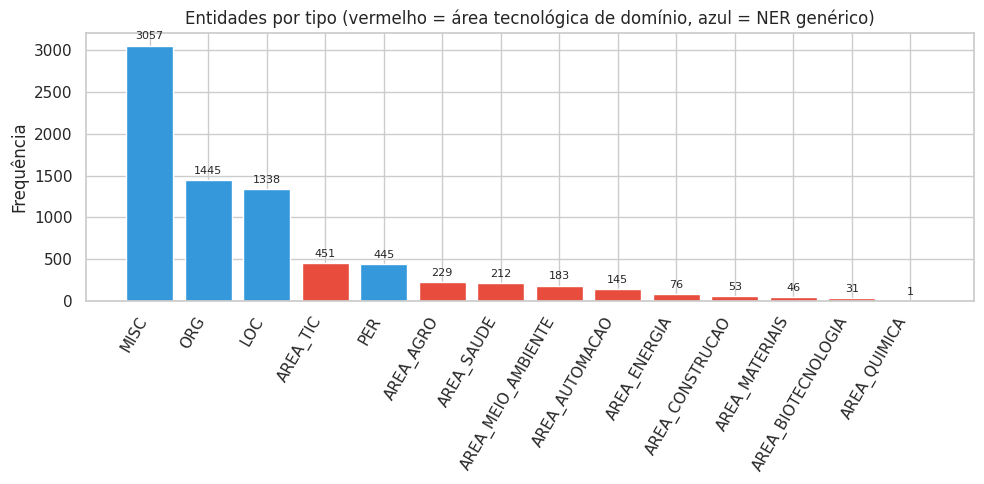

In [17]:
label_counts = df_entidades["label"].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(10, 5))
cores = ["#e74c3c" if l.startswith("AREA_") else "#3498db" for l in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=cores, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set_title("Entidades por tipo (vermelho = área tecnológica de domínio, azul = NER genérico)")
ax.set_ylabel("Frequência")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


In [18]:
# Matriz de contagem de entidades de ÁREA por projeto (vira feature na clusterização)
LABELS_AREA = list(TECH_AREAS.keys())

if len(df_entidades) > 0:
    contagem_ent = (
        df_entidades[df_entidades["label"].isin(LABELS_AREA)]
        .groupby(["id_projeto", "label"]).size().unstack(fill_value=0)
    )
    contagem_ent = contagem_ent.reindex(columns=LABELS_AREA, fill_value=0)
    contagem_ent = contagem_ent.reindex(df["id_projeto"], fill_value=0)
else:
    contagem_ent = pd.DataFrame(0, index=df["id_projeto"], columns=LABELS_AREA)

contagem_ent.head()


label,AREA_AGRO,AREA_SAUDE,AREA_TIC,AREA_ENERGIA,AREA_MATERIAIS,AREA_QUIMICA,AREA_BIOTECNOLOGIA,AREA_AUTOMACAO,AREA_MEIO_AMBIENTE,AREA_CONSTRUCAO
id_projeto,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,2,0
4,0,0,0,0,0,0,0,0,1,0


In [19]:
# Exemplo visual: entidades destacadas em um projeto
from spacy import displacy

exemplo_ner = df["texto"].iloc[0]
doc_ner_exemplo = nlp(exemplo_ner)
displacy.render(doc_ner_exemplo, style="ent", jupyter=True)


## 6. Transformers (Vaswani et al., 2017) - base do projeto

O artigo "Attention Is All You Need" (Vaswani et al., 2017) introduziu a arquitetura
Transformer, cujo componente central é a atenção (self-attention): para cada token, o modelo
aprende para quais outros tokens da frase "olhar", combinando três projeções lineares -
Query ($Q$), Key ($K$) e Value ($V$):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Antes de usar o modelo pré-treinado, essa fórmula é implementada na mão com numpy, apenas
para visualizar na prática o que a atenção calcula.

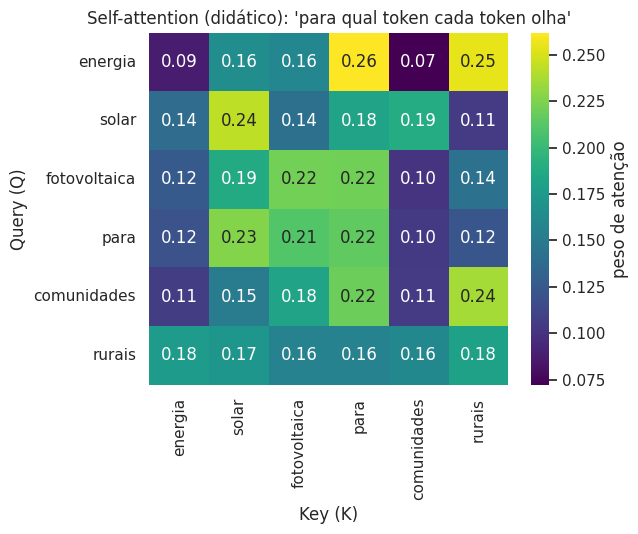

Cada linha soma 1.0 (é uma distribuição de probabilidade via softmax) — confira: [1. 1. 1. 1. 1. 1.]


In [20]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def self_attention_didatico(tokens, dim=8, seed=RANDOM_STATE):
    # Self-attention de um único "head", com Q/K/V gerados aleatoriamente
    # apenas para fins didáticos (ilustra a fórmula, não é um modelo treinado).
    rng = np.random.default_rng(seed)
    n = len(tokens)
    X = rng.normal(size=(n, dim))  # embeddings "de brinquedo"

    Wq, Wk, Wv = (rng.normal(size=(dim, dim)) * 0.3 for _ in range(3))
    Q, K, V = X @ Wq, X @ Wk, X @ Wv

    scores = (Q @ K.T) / np.sqrt(dim)
    pesos_atencao = softmax(scores, axis=-1)
    saida = pesos_atencao @ V
    return pesos_atencao, saida

tokens_exemplo = ["energia", "solar", "fotovoltaica", "para", "comunidades", "rurais"]
pesos_atencao, _ = self_attention_didatico(tokens_exemplo)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    pesos_atencao, annot=True, fmt=".2f", cmap="viridis",
    xticklabels=tokens_exemplo, yticklabels=tokens_exemplo, cbar_kws={"label": "peso de atenção"}, ax=ax,
)
ax.set_title("Self-attention (didático): 'para qual token cada token olha'")
ax.set_xlabel("Key (K)")
ax.set_ylabel("Query (Q)")
plt.tight_layout()
plt.show()
print("Cada linha soma 1.0 (é uma distribuição de probabilidade via softmax) — confira:", pesos_atencao.sum(axis=1).round(3))


### 6.1 BERTimbau - o Transformer usado de fato

Treinar um Transformer do zero exigiria um corpus e um poder computacional bem maiores, então
a abordagem aqui é transfer learning: o BERTimbau (neuralmind/bert-base-portuguese-cased) é
um encoder Transformer (a parte "BERT" da arquitetura original) já pré-treinado num corpus
grande em português. Cada texto passa pelo modelo e recebe mean pooling (média dos vetores de
saída de todos os tokens, ponderada pela máscara de atenção), chegando a um único vetor de 768
dimensões por projeto. Esse vetor é a base tanto da busca vetorial (seção 8) quanto da
clusterização (seção 9).

In [21]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"  # BERTimbau

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
bert_model.eval()
print(f"Modelo carregado: {MODEL_NAME} | parâmetros: {sum(p.numel() for p in bert_model.parameters()):,}")


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado: neuralmind/bert-base-portuguese-cased | parâmetros: 108,923,136


In [22]:
def mean_pooling(saida_modelo, attention_mask):
    token_embeddings = saida_modelo.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    soma = torch.sum(token_embeddings * mask, dim=1)
    contagem = torch.clamp(mask.sum(dim=1), min=1e-9)
    return soma / contagem

@torch.no_grad()
def gerar_embeddings(textos, batch_size=16, max_length=256):
    todos = []
    for i in range(0, len(textos), batch_size):
        batch = textos[i:i + batch_size]
        enc = tokenizer(
            batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt",
        ).to(DEVICE)
        saida = bert_model(**enc)
        emb = mean_pooling(saida, enc["attention_mask"])
        todos.append(emb.cpu().numpy())
    return np.vstack(todos)

embeddings_bert = gerar_embeddings(df["texto"].tolist())
print("Shape dos embeddings BERT:", embeddings_bert.shape)


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Shape dos embeddings BERT: (2705, 768)


## 7. TF-IDF - termos discriminantes

O BERT captura semântica geral, mas um bloco de TF-IDF sobre o texto lematizado ajuda a
preservar termos técnicos exatos que diferenciam os projetos (como "fotovoltaica",
"biopesticida"), o que reforça a clusterização mais adiante.

Shape TF-IDF: (2705, 300)


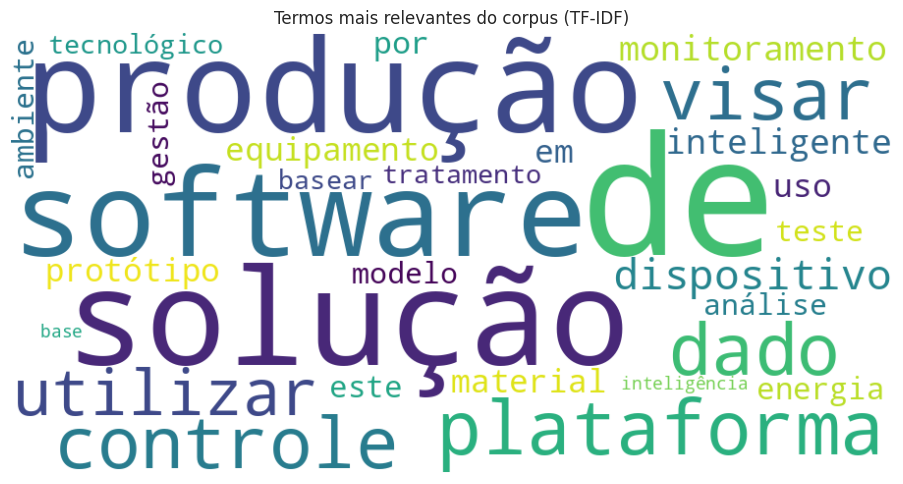

In [23]:
tfidf = TfidfVectorizer(max_features=300, min_df=2, max_df=0.6, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["texto_processado"])
termos = np.array(tfidf.get_feature_names_out())
print("Shape TF-IDF:", X_tfidf.shape)

soma_tfidf = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_geral = pd.Series(soma_tfidf, index=termos).sort_values(ascending=False).head(30)

wc = WordCloud(width=900, height=450, background_color="white", colormap="viridis")
wc.generate_from_frequencies(top_geral.to_dict())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Termos mais relevantes do corpus (TF-IDF)")
plt.tight_layout()
plt.show()


## 8. MiniLAB - busca vetorial semântica com BERT

Esta é a parte do MiniLAB: dado um texto de consulta livre, gera-se o embedding dele com o
mesmo BERTimbau e recupera-se, por similaridade de cosseno, os projetos mais próximos no
espaço vetorial. É uma busca semântica de fato, que encontra projetos relevantes mesmo sem
usar as mesmas palavras-chave - diferente de uma busca por TF-IDF ou palavra exata.

In [24]:
def busca_semantica(consulta, top_k=5):
    emb_consulta = gerar_embeddings([consulta])
    similaridades = cosine_similarity(emb_consulta, embeddings_bert)[0]
    top_idx = similaridades.argsort()[::-1][:top_k]
    resultado = df.iloc[top_idx][["id_projeto", "titulo_limpo", "texto"]].copy()
    resultado["similaridade"] = similaridades[top_idx].round(4)
    resultado["texto"] = resultado["texto"].str.slice(0, 160) + "..."
    return resultado.reset_index(drop=True)

consultas_exemplo = [
    "energia solar fotovoltaica em comunidades rurais",
    "inteligência artificial aplicada ao diagnóstico médico",
    "biopesticida para controle de pragas agrícolas",
    "reciclagem de resíduos e economia circular",
]

for consulta in consultas_exemplo:
    print(f"\n{'='*100}\nCONSULTA: \"{consulta}\"\n{'='*100}")
    display(busca_semantica(consulta, top_k=5))



CONSULTA: "energia solar fotovoltaica em comunidades rurais"


,id_projeto,titulo_limpo,texto,similaridade
0,876,Sistema de ancoragem e de posição dinâmica par...,Sistema de ancoragem e de posição dinâmica par...,0.7131
1,1558,Desenvolvimento de módulos de concretos acopla...,Desenvolvimento de módulos de concretos acopla...,0.7089
2,2206,Biotecnologia para solventes verdes,Biotecnologia para solventes verdes. Otimizar ...,0.7082
3,783,TELHA SOLAR FOTOVOLTAICA PERKUS,TELHA SOLAR FOTOVOLTAICA PERKUS. O projeto obj...,0.7074
4,2231,Produção de biocombustíveis drop in a partir d...,Produção de biocombustíveis drop in a partir d...,0.7042



CONSULTA: "inteligência artificial aplicada ao diagnóstico médico"


,id_projeto,titulo_limpo,texto,similaridade
0,188,Parlametria-IA,Parlametria-IA. Desenvolvimento de software us...,0.6362
1,222,S3DSIM,S3DSIM. Este projeto objetiva desenvolver um s...,0.6097
2,324,FORECAST,FORECAST. O presente projeto visa investigar i...,0.6095
3,440,Sistema especialista de avaliação de pacientes...,Sistema especialista de avaliação de pacientes...,0.6067
4,235,SIE,SIE. Sistema móvel para realização de operaçõe...,0.6034



CONSULTA: "biopesticida para controle de pragas agrícolas"


,id_projeto,titulo_limpo,texto,similaridade
0,1539,Composto botânico para controle de pragas agrí...,Composto botânico para controle de pragas agrí...,0.8403
1,1217,Desenvolvimento de bioinsumos para controle de...,Desenvolvimento de bioinsumos para controle de...,0.8252
2,1216,Desenvolvimento de biofungicida e biopesticida,Desenvolvimento de biofungicida e biopesticida...,0.7972
3,1233,Desenvolvimento de um biopesticida a base do f...,Desenvolvimento de um biopesticida a base do f...,0.7851
4,1211,Controle de pragas com óleos essenciais,Controle de pragas com óleos essenciais. Desen...,0.7795



CONSULTA: "reciclagem de resíduos e economia circular"


,id_projeto,titulo_limpo,texto,similaridade
0,2113,Embalagens sustentáveis de baixo custo e densi...,Embalagens sustentáveis de baixo custo e densi...,0.7074
1,712,Projeto ASSOBEGE,Projeto ASSOBEGE. Este projeto tem por finalid...,0.6864
2,1535,Sistema Integrado de Resíduos,Sistema Integrado de Resíduos. Implantar um si...,0.6627
3,2151,TR-S,TR-S. Desenvolvimento de materiais sustentávei...,0.6602
4,2111,Ecotubos,Ecotubos. Desenvolvimento de composto termoplá...,0.6453


In [25]:
# Espaço para você testar sua própria consulta:
minha_consulta = "monitoramento de saúde animal com sensores IoT"  # <-- edite livremente
display(busca_semantica(minha_consulta, top_k=5))


,id_projeto,titulo_limpo,texto,similaridade
0,173,Mr Carson,Mr Carson. Sistema de controle e monitoramento...,0.7779
1,33,ADRs,ADRs. Software embarcado para central de monit...,0.7725
2,244,SMART BED,SMART BED. Sistema embarcado para central de m...,0.7683
3,174,MRP,MRP. Solução de software para monitoramenteo d...,0.7640
4,460,ATAS - Monitoramento de gases medicinais,ATAS - Monitoramento de gases medicinais. Dese...,0.7463


## 9. Espaço vetorial combinado (BERT + TF-IDF + NER)

Para a clusterização, combinam-se os três blocos de features montados até aqui:

1. BERT (768 dimensões), reduzido via PCA para capturar a semântica geral com menos ruído;
2. TF-IDF (300 dimensões, esparso), reduzido via SVD (o equivalente do PCA para matriz esparsa);
3. contagem de entidades de área extraídas pelo NER (10 dimensões), suavizada com log1p.

Cada bloco é padronizado e tem a variância total equalizada para ~1, para que nenhum bloco
domine a distância do KMeans só por ter mais colunas - sem isso, o bloco do BERT (768 colunas)
atropelaria facilmente o bloco de NER (10 colunas).

In [26]:
def bloco_padronizado(X, n_components=None, whiten=False, random_state=RANDOM_STATE):
    if n_components is not None:
        n_components = min(n_components, X.shape[0] - 1, X.shape[1])
        reducer = PCA(n_components=n_components, whiten=whiten, random_state=random_state) if not hasattr(X, "toarray") \
            else TruncatedSVD(n_components=n_components, random_state=random_state)
        X = reducer.fit_transform(X)
    else:
        X = StandardScaler().fit_transform(X.toarray() if hasattr(X, "toarray") else X)
    X = np.asarray(X)
    return X / np.sqrt(X.shape[1])

PESO_BERT, PESO_TFIDF, PESO_NER = 1.0, 0.8, 0.6

bloco_bert = bloco_padronizado(embeddings_bert, n_components=100) * PESO_BERT
bloco_tfidf = bloco_padronizado(X_tfidf, n_components=100) * PESO_TFIDF
bloco_ner = bloco_padronizado(np.log1p(contagem_ent.values)) * PESO_NER

X_combinado = np.hstack([bloco_bert, bloco_tfidf, bloco_ner])
print("Shape final do espaço combinado:", X_combinado.shape)


Shape final do espaço combinado: (2705, 210)


## 10. Clusterização (KMeans) - escolha de k

São testados valores de k de 2 a 10, olhando três métricas de validação em conjunto:
silhouette (quanto maior, melhor), Calinski-Harabasz (quanto maior, melhor) e Davies-Bouldin
(quanto menor, melhor). Usar só o silhouette em espaços de alta dimensão costuma favorecer
divisões triviais em dois grupos, por isso a escolha de olhar as três métricas juntas.

In [27]:
K_MIN, K_MAX = 2, 10
resultados_k = []
for k in range(K_MIN, K_MAX + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_combinado)
    resultados_k.append({
        "k": k,
        "silhouette": silhouette_score(X_combinado, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X_combinado, labels_k),
        "davies_bouldin": davies_bouldin_score(X_combinado, labels_k),
    })
df_k = pd.DataFrame(resultados_k)
K_OTIMO = int(df_k.loc[df_k["silhouette"].idxmax(), "k"])
print(f"k sugerido pelo silhouette: {K_OTIMO}")
df_k


k sugerido pelo silhouette: 2


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.635859,224.965910,0.648882
1,3,0.192639,234.857418,1.621482
2,4,0.205583,250.886837,1.195345
3,5,0.359983,275.254247,0.767880
4,6,0.230307,300.831289,1.060566
5,7,0.241213,328.854717,0.934750
6,8,0.281104,360.967432,1.205018
7,9,0.330071,409.817152,0.920683
8,10,0.303742,458.721695,0.826992


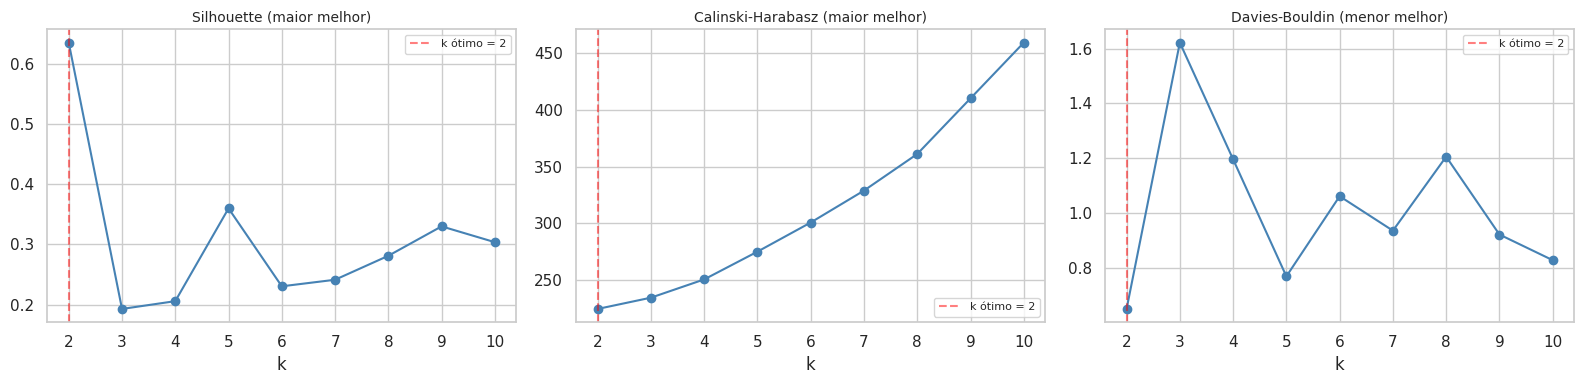

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metricas = [("silhouette", "Silhouette (maior melhor)"), ("calinski_harabasz", "Calinski-Harabasz (maior melhor)"),
            ("davies_bouldin", "Davies-Bouldin (menor melhor)")]
for ax, (col, titulo) in zip(axes, metricas):
    ax.plot(df_k["k"], df_k[col], "o-", color="steelblue")
    ax.axvline(K_OTIMO, color="red", linestyle="--", alpha=0.5, label=f"k ótimo = {K_OTIMO}")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("k")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [29]:
# k final: usamos o nº de áreas tecnológicas mapeadas pelo NER (mais interpretável para o
# negócio) — troque K_MANUAL por None para usar apenas o k estatisticamente ótimo (K_OTIMO).
K_MANUAL = len(LABELS_AREA)
K_FINAL = K_MANUAL if K_MANUAL is not None else K_OTIMO

modelo_kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = modelo_kmeans.fit_predict(X_combinado)

print(f"k final utilizado: {K_FINAL}")
df["cluster"].value_counts().sort_index()


k final utilizado: 10


,count
cluster,
0,1904
1,26
2,322
3,31
4,128
5,42
6,106
7,1
8,39


## 11. Interpretação dos clusters

Para cada cluster são observados (a) os termos de TF-IDF mais fortes dentro dele - não do
corpus geral - e (b) a distribuição das entidades de área mais frequentes. As duas fontes
juntas dão uma boa ideia do "rótulo" temático de cada grupo.

In [30]:
def termos_por_cluster(X_tfidf, termos, clusters, top_n=10):
    linhas = []
    for c in sorted(set(clusters)):
        idx = np.where(clusters == c)[0]
        soma = np.asarray(X_tfidf[idx].sum(axis=0)).ravel()
        top_idx = soma.argsort()[::-1][:top_n]
        linhas.append({"cluster": c, "n_projetos": len(idx), "top_termos": ", ".join(termos[top_idx])})
    return pd.DataFrame(linhas)

df_termos_cluster = termos_por_cluster(X_tfidf, termos, df["cluster"].values)
df_termos_cluster


,cluster,n_projetos,top_termos
0,0,1904,"de, solução, produção, visar, plataforma, util..."
1,1,26,"controle, praga, produção, de, base, cultura, ..."
2,2,322,"software, plataforma, dado, de, dispositivo, s..."
3,3,31,"revestimento, material, de, alto, utilizar, fo..."
4,4,128,"tratamento, paciente, de, doença, saúde, uso, ..."
5,5,42,"bateria, energia, de, elétrico, geração, protó..."
6,6,106,"sensor, de, monitoramento, dado, dispositivo, ..."
7,7,1,"potencial, de, estrutura, de isso, isso, melho..."
8,8,39,"de, produção, solução, construção, dado, monit..."
9,9,106,"praga, de, solo, controle, cultura, agrícola, ..."


In [31]:
df_ent_cluster = df_entidades.merge(df[["id_projeto", "cluster"]], on="id_projeto", how="left")
top_ent_cluster = (
    df_ent_cluster[df_ent_cluster["label"].isin(LABELS_AREA)]
    .groupby(["cluster", "label"]).size()
    .reset_index(name="qtde")
    .sort_values(["cluster", "qtde"], ascending=[True, False])
)

# Área tecnológica dominante por cluster (maior contagem de entidade AREA_*)
area_dominante = (
    top_ent_cluster.sort_values("qtde", ascending=False)
    .drop_duplicates(subset="cluster")
    .set_index("cluster")["label"]
    .rename("area_dominante")
)

tabela_final = df_termos_cluster.set_index("cluster").join(area_dominante).reset_index()
tabela_final


,cluster,n_projetos,top_termos,area_dominante
0,0,1904,"de, solução, produção, visar, plataforma, util...",AREA_MEIO_AMBIENTE
1,1,26,"controle, praga, produção, de, base, cultura, ...",AREA_AGRO
2,2,322,"software, plataforma, dado, de, dispositivo, s...",AREA_TIC
3,3,31,"revestimento, material, de, alto, utilizar, fo...",AREA_MATERIAIS
4,4,128,"tratamento, paciente, de, doença, saúde, uso, ...",AREA_SAUDE
5,5,42,"bateria, energia, de, elétrico, geração, protó...",AREA_ENERGIA
6,6,106,"sensor, de, monitoramento, dado, dispositivo, ...",AREA_AUTOMACAO
7,7,1,"potencial, de, estrutura, de isso, isso, melho...",AREA_QUIMICA
8,8,39,"de, produção, solução, construção, dado, monit...",AREA_CONSTRUCAO
9,9,106,"praga, de, solo, controle, cultura, agrícola, ...",AREA_AGRO


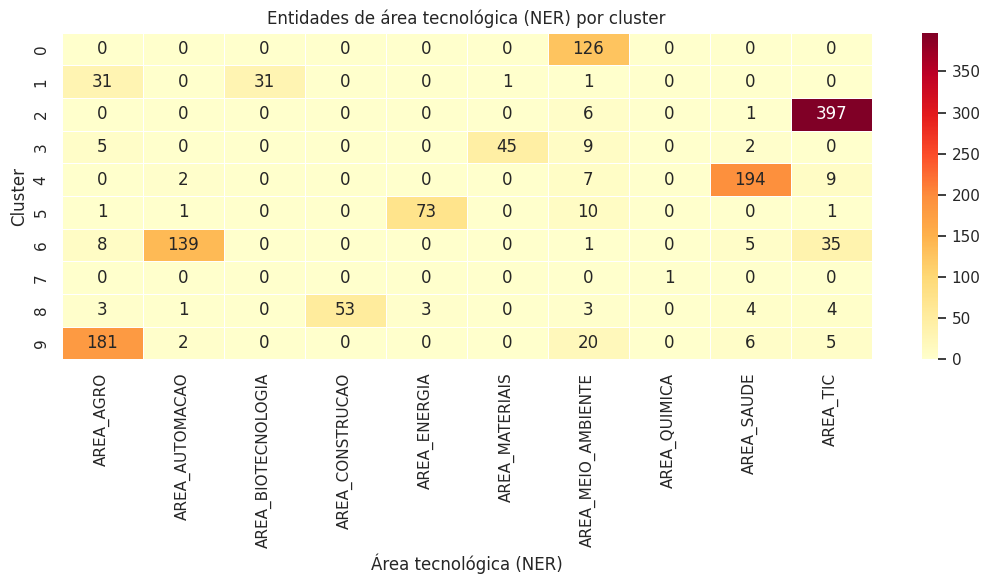

In [32]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot_ent = top_ent_cluster.pivot(index="cluster", columns="label", values="qtde").fillna(0)
sns.heatmap(pivot_ent, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.4, ax=ax)
ax.set_title("Entidades de área tecnológica (NER) por cluster")
ax.set_xlabel("Área tecnológica (NER)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()


## 12. Visualização dos clusters (PCA e t-SNE)

O PCA dá uma visão global e linear da separação entre os clusters. Já o t-SNE é não-linear e
costuma revelar subgrupos e nuances locais que o PCA acaba achatando.

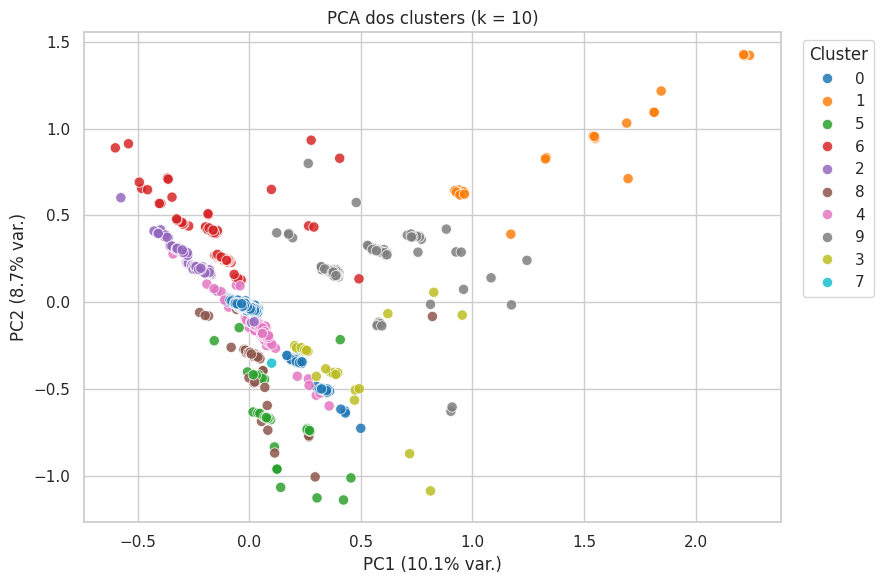

In [33]:
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_viz = pca_viz.fit_transform(X_combinado)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca_viz[:, 0], y=X_pca_viz[:, 1], hue=df["cluster"].astype(str), palette="tab10", s=55, alpha=0.85)
plt.xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title(f"PCA dos clusters (k = {df['cluster'].nunique()})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


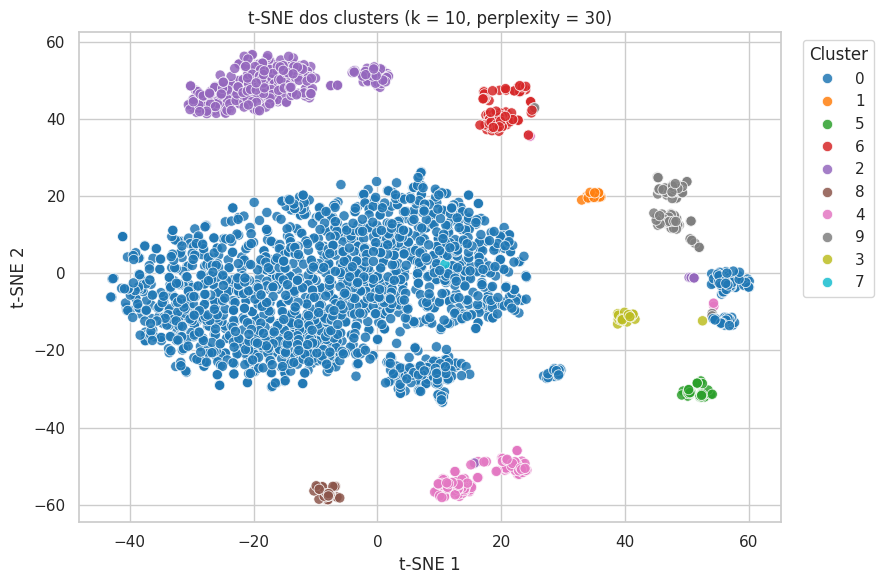

In [34]:
perplexity = min(30, max(5, len(df) // 5))
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=perplexity, init="pca")
X_tsne = tsne.fit_transform(X_combinado)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["cluster"].astype(str), palette="tab10", s=55, alpha=0.85)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"t-SNE dos clusters (k = {df['cluster'].nunique()}, perplexity = {perplexity})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


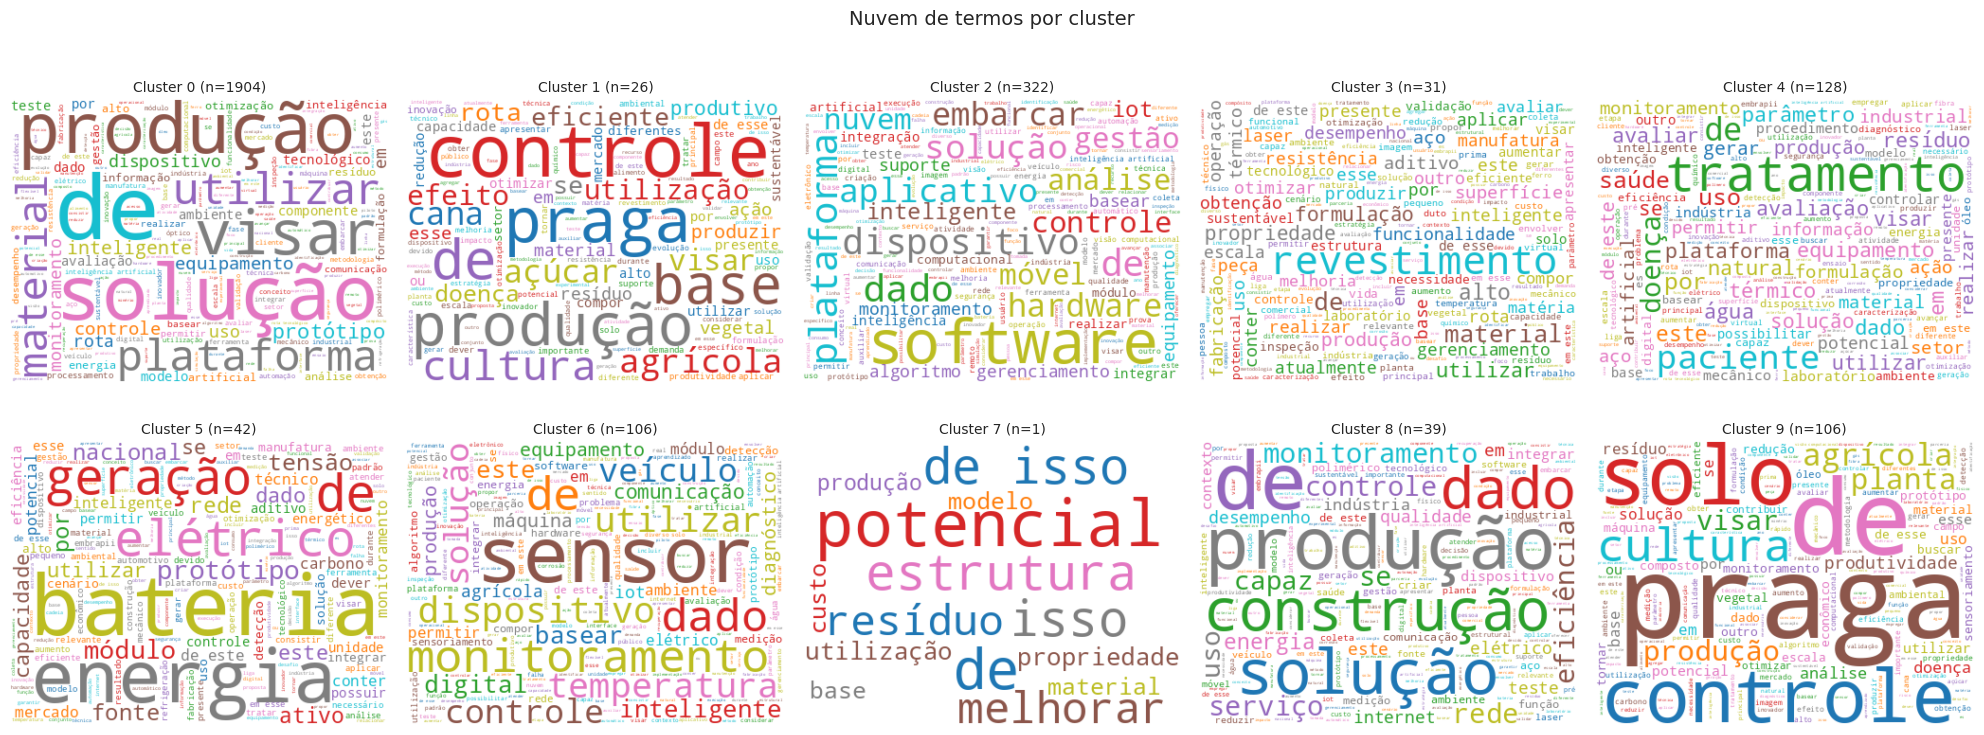

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for c, ax in zip(sorted(df["cluster"].unique()), axes.ravel()):
    idx = np.where(df["cluster"].values == c)[0]
    soma = np.asarray(X_tfidf[idx].sum(axis=0)).ravel()
    freqs = dict(zip(termos, soma))
    freqs = {k_: v for k_, v in freqs.items() if v > 0}
    if not freqs:
        ax.axis("off")
        continue
    wc = WordCloud(width=400, height=300, background_color="white", colormap="tab10").generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Cluster {c} (n={len(idx)})", fontsize=10)
    ax.axis("off")
plt.suptitle("Nuvem de termos por cluster", fontsize=14)
plt.tight_layout()
plt.show()


## 13. Bônus: busca vetorial dentro de um cluster específico

Juntando os dois pilares do projeto - a clusterização (NER + BERT + TF-IDF) e a busca vetorial
do MiniLAB - é possível restringir a busca semântica a um cluster específico. Serve, por
exemplo, para achar o projeto mais parecido dentro da mesma área tecnológica.

In [36]:
def busca_semantica_no_cluster(consulta, cluster_id, top_k=5):
    emb_consulta = gerar_embeddings([consulta])
    idx_cluster = df.index[df["cluster"] == cluster_id].tolist()
    similaridades = cosine_similarity(emb_consulta, embeddings_bert[idx_cluster])[0]
    ordem = similaridades.argsort()[::-1][:top_k]
    idx_top = [idx_cluster[i] for i in ordem]
    resultado = df.loc[idx_top, ["id_projeto", "titulo_limpo", "cluster"]].copy()
    resultado["similaridade"] = similaridades[ordem].round(4)
    return resultado.reset_index(drop=True)

cluster_exemplo = int(df["cluster"].value_counts().idxmax())  # cluster mais populoso, só para demonstrar
print(f"Buscando dentro do cluster {cluster_exemplo}...")
display(busca_semantica_no_cluster("uso de sensores para monitoramento remoto", cluster_exemplo, top_k=5))


Buscando dentro do cluster 0...


,id_projeto,titulo_limpo,cluster,similaridade
0,239,Sistema de monitoramento e controle para inver...,0,0.8093
1,1738,Plataforma de monitoramento remoto de geradores,0,0.8058
2,918,Desenvolvimento do Fence Smart.,0,0.8046
3,263,TermMonitor,0,0.8042
4,73,Controle remoto de carregamento de baterias,0,0.7956


## 14. Exportação dos resultados

In [37]:
PASTA_SAIDA = "/content/resultados"
os.makedirs(PASTA_SAIDA, exist_ok=True)

df_export = df[[
    "id_projeto", "titulo_limpo", "descricao_limpa", "texto",
    "entidades", "cluster",
]].copy()
df_export.to_csv(f"{PASTA_SAIDA}/projetos_clusterizados.csv", index=False, encoding="utf-8-sig")
df_entidades.to_csv(f"{PASTA_SAIDA}/entidades_extraidas.csv", index=False, encoding="utf-8-sig")
tabela_final.to_csv(f"{PASTA_SAIDA}/resumo_clusters.csv", index=False, encoding="utf-8-sig")
np.save(f"{PASTA_SAIDA}/embeddings_bert.npy", embeddings_bert)

print(f"Arquivos exportados em: {PASTA_SAIDA}")
for f in os.listdir(PASTA_SAIDA):
    print(" -", f)

# Opcional: salvar no Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r /content/resultados /content/drive/MyDrive/


Arquivos exportados em: /content/resultados
 - resumo_clusters.csv
 - embeddings_bert.npy
 - projetos_clusterizados.csv
 - entidades_extraidas.csv


## 15. Conclusões

O pré-processamento com spaCy (lematização + stopwords de domínio) ajudou a limpar o
vocabulário sem perder os termos técnicos que realmente diferenciam os projetos, o que se
refletiu num TF-IDF mais "limpo". A distribuição de POS confirmou o esperado: os textos têm
bastante substantivo e adjetivo, típico de resumo técnico. O EntityRuler de domínio deu
conta de mapear os projetos por área tecnológica sem a necessidade de treinar um NER do zero,
o que seria bem mais trabalhoso com a quantidade de dados disponível.

O ponto mais interessante foi observar como os embeddings do BERTimbau conseguem captar
semelhança entre projetos que nem compartilham vocabulário parecido - isso aparece tanto na
clusterização quanto na busca vetorial da seção 8, que era o objetivo principal do projeto.
A combinação de BERT + TF-IDF + NER (com os blocos normalizados) também gerou grupos bem mais
interpretáveis do que qualquer uma das três fontes usada sozinha, o que fica visível no
heatmap da seção 11, onde a maioria dos clusters tem uma ou duas áreas bem dominantes.

Como pontos de melhoria: o EntityRuler é baseado em regras, então um NER treinado com
exemplos anotados provavelmente generalizaria melhor para termos fora dos dicionários usados
aqui. Também seria possível testar um BERT maior ou fine-tunado especificamente no domínio de
P&D&I, além de avaliar a busca vetorial de forma mais quantitativa, com um conjunto de
consultas e gabarito de relevância (Precision@k / Recall@k) - fica como próximo passo.
